******Лабораторна робота №1 “Зменшення розмірності даних”******


**Мета:**
Ознайомитися з основами зменшення розмірності даних (dimensionality reduction) на прикладі зображень рукописних цифр із набору MNIST. Навчитись виконувати метод головних компонент (PCA), інтерпретувати отримані результати, оцінювати втрату інформації після проєкції та реконструкції зображень.


У даній роботі використано набір даних MNIST, який є стандартним еталонним датасетом для задач комп’ютерного зору та машинного навчання. Набір містить 70000 зображень рукописних цифр від 0 до 9. Кожне зображення має розмір 28×28 пікселів і представлено у вигляді вектора розмірності 784, що відповідає кількості пікселів. Таким чином, вхідна матриця даних має розмір 70000 × 784, де кожен рядок відповідає окремому зображенню. Мітки класів задають відповідну цифру для кожного зображення. Така висока розмірність простору ознак робить дані зручним прикладом для дослідження методів зменшення розмірності.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Unique labels:", np.unique(y))


Shape of X: (70000, 784)
Shape of y: (70000,)
Unique labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


In [3]:
from sklearn.decomposition import PCA

y = y.astype(int)

pca3 = PCA(n_components=3, random_state=42)

# проєкція
X_pca = pca3.fit_transform(X)

print("Shape of X_pca:", X_pca.shape)
print("Explained variance ratio:", pca3.explained_variance_ratio_)
print("Total explained variance:", pca3.explained_variance_ratio_.sum())

Shape of X_pca: (70000, 3)
Explained variance ratio: [0.09746116 0.07155445 0.06149531]
Total explained variance: 0.230510914900965


Проєкція даних у простір трьох головних компонент

У роботі було виконано зменшення розмірності даних MNIST із 784 до 3 головних компонент. Отримана матриця проєкцій має розмір 70000 × 3. Сумарна пояснена дисперсія для трьох компонент становить приблизно 23%, що означає, що збережено лише частину загальної варіативності даних. Побудована тривимірна візуалізація показала наявність часткового групування точок відповідно до класів цифр, однак повного розділення не спостерігається. Це пояснюється тим, що PCA максимізує дисперсію даних, а не розділення класів, тому перекриття між цифрами з подібною формою є неминучим.

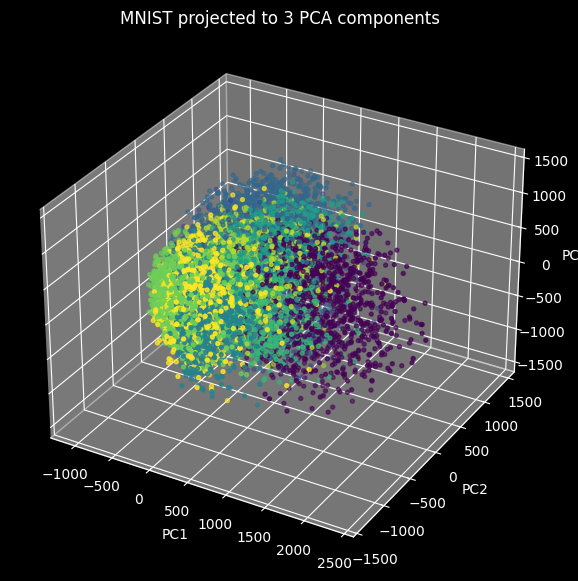

In [4]:
from mpl_toolkits.mplot3d import Axes3D

rng = np.random.default_rng(42)
idx = rng.choice(X_pca.shape[0], 10000, replace=False)

Xp = X_pca[idx]
yp = y[idx]

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    Xp[:,0],
    Xp[:,1],
    Xp[:,2],
    c=yp,
    s=8
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("MNIST projected to 3 PCA components")

plt.show()

In [5]:
X_reconstructed = pca3.inverse_transform(X_pca)

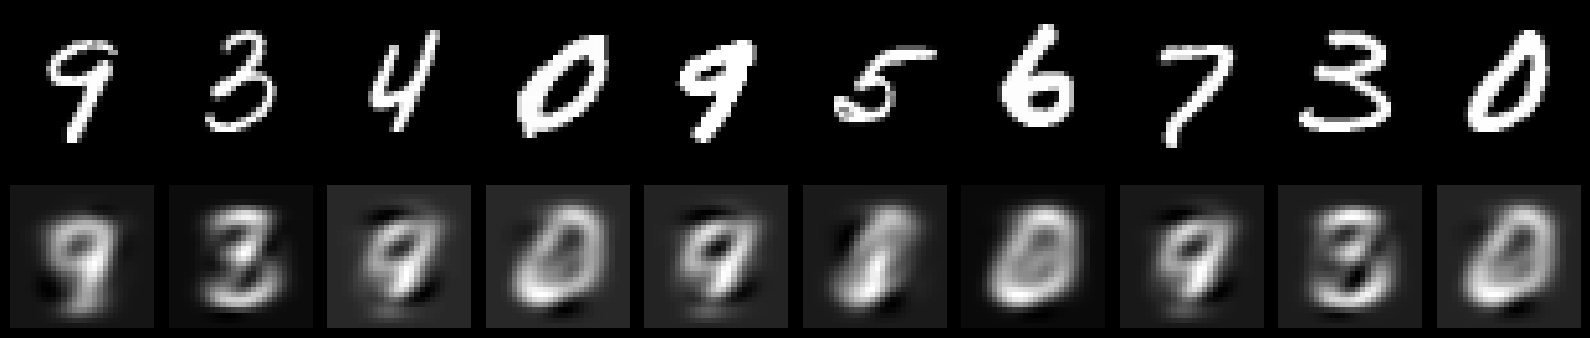

In [6]:
rng = np.random.default_rng(7)
indices = rng.choice(X.shape[0], 10, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(16, 4))

for j, idx in enumerate(indices):
    axes[0, j].imshow(X[idx].reshape(28, 28), cmap="gray")
    axes[0, j].axis("off")

    axes[1, j].imshow(X_reconstructed[idx].reshape(28, 28), cmap="gray")
    axes[1, j].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Reconstructed", fontsize=12)

plt.tight_layout()
plt.show()

Після проєкції у простір трьох головних компонент було виконано зворотне перетворення даних у початковий простір ознак за допомогою функції inverse_transform. Візуальний аналіз реконструйованих зображень показав розмиття контурів. Збереглася лише загальна форма цифр. Обчислена середньоквадратична помилка реконструкції становить приблизно 3366, що підтверджує значну втрату інформації при використанні лише трьох компонент.

In [7]:
mse = np.mean((X - X_reconstructed) ** 2)
print("Reconstruction MSE (k=3):", mse)

Reconstruction MSE (k=3): 3366.4896679948856


In [8]:
from sklearn.decomposition import PCA

rng = np.random.default_rng(42)
subset_idx = rng.choice(X.shape[0], 20000, replace=False)
X_subset = X[subset_idx]

ks = [1, 2, 3, 5, 10, 20, 50, 100, 200]
mses = []
explained = []

for k in ks:
    pca = PCA(n_components=k, random_state=42)
    Z = pca.fit_transform(X_subset)
    X_hat = pca.inverse_transform(Z)

    mse_k = np.mean((X_subset - X_hat) ** 2)

    mses.append(mse_k)
    explained.append(np.sum(pca.explained_variance_ratio_))

print("k values:", ks)
print("MSE:", mses)
print("Explained variance:", explained)

k values: [1, 2, 3, 5, 10, 20, 50, 100, 200]
MSE: [np.float64(3943.813668699025), np.float64(3629.0320242312678), np.float64(3360.450935932766), np.float64(2912.313294235261), np.float64(2229.430239648137), np.float64(1549.510730644468), np.float64(758.3799790473545), np.float64(368.4668528593486), np.float64(144.02726117432346)]
Explained variance: [np.float64(0.09837654685148864), np.float64(0.17034103024616443), np.float64(0.2317432740195027), np.float64(0.334195225844707), np.float64(0.49031400565931016), np.float64(0.6457552681196519), np.float64(0.8266213282502942), np.float64(0.9157621571012504), np.float64(0.96707289758688)]


Після проведення експериментального дослідження залежності середньоквадратичної помилки реконструкції та сумарної поясненої дисперсії від кількості головних компонент k. Отримані результати показали, що при зростанні k значення MSE монотонно зменшується, що свідчить про покращення точності відновлення зображень. Водночас сумарна пояснена дисперсія швидко зростає при малих значеннях k та поступово наближається до насичення при більших значеннях.

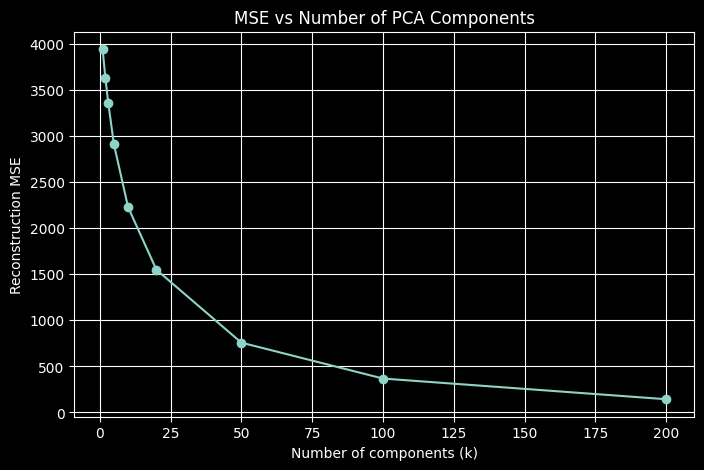

In [9]:
plt.figure(figsize=(8,5))
plt.plot(ks, mses, marker='o')
plt.xlabel("Number of components (k)")
plt.ylabel("Reconstruction MSE")
plt.title("MSE vs Number of PCA Components")
plt.grid(True)
plt.show()

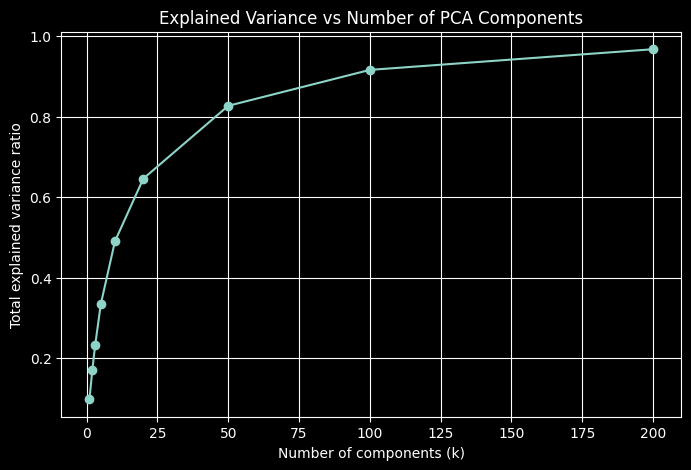

In [10]:
plt.figure(figsize=(8,5))
plt.plot(ks, explained, marker='o')
plt.xlabel("Number of components (k)")
plt.ylabel("Total explained variance ratio")
plt.title("Explained Variance vs Number of PCA Components")
plt.grid(True)
plt.show()

**Висновок**

У ході лабораторної роботи було досліджено застосування методу головних компонент для зменшення розмірності набору зображень MNIST. Показано, що PCA дозволяє суттєво зменшити розмірність простору ознак із 784 до значно меншої кількості компонент із контрольованою втратою інформації. Було встановлено, що якість реконструкції безпосередньо залежить від кількості збережених компонент, а компроміс між ступенем стиснення та точністю відновлення визначається вимогами конкретної задачі. Метод головних компонент продемонстрував ефективність як інструмент попередньої обробки даних високої розмірності та збереження їх основної структури.